# Détection de Fake News Arabes — Fine-tuning AraBERT (Optimisé T4)

**Modèle :** `aubmindlab/bert-base-arabertv02` (ou large en option)  
**Données :** 10 000 articles fake + 10 000 articles réels  
**Optimisations T4 :**
- Préprocessing Farasa **une seule fois** (≈ 80 % de gain de vitesse)
- Tokenisation **pré-calculée** avant l'entraînement
- Titre + texte concaténés → plus de signal pour le modèle
- fp16 + cosine scheduler + label smoothing
- Sauvegarde directe sur Drive (persistance inter-sessions)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Section 1 — Librairies

In [2]:
!pip install -q transformers datasets scikit-learn pandas numpy \
    matplotlib seaborn accelerate arabert sentencepiece
print("Installation terminée ✓")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 6.1 MB/s eta 0:00:00
Installation terminée ✓


In [3]:
import json, random, gc, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc, classification_report
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Section 2 — Chargement des données

In [4]:
FAKE_PATH = "/content/drive/MyDrive/fake_news_dataset_10k.json"
REAL_PATH = "/content/drive/MyDrive/Real_news_dataset_10k.json"

with open(FAKE_PATH, "r", encoding="utf-8") as f:
    fake_raw = json.load(f).get("articles", [])
with open(REAL_PATH, "r", encoding="utf-8") as f:
    real_raw = json.load(f).get("articles", [])

print(f"Fake : {len(fake_raw):,} articles")
print(f"Real : {len(real_raw):,} articles")
print("Colonnes :", list(fake_raw[0].keys()))

Fake : 10,000 articles
Real : 10,000 articles
Colonnes : ['published_date', 'title', 'text', 'category', 'category_score', 'matched_keywords', 'label']


## Section 3 — Fusion & construction du DataFrame

**Amélioration clé : Titre + Texte**  
On concatène le titre et le texte avec un token `[SEP]`.  
Le titre contient souvent les indicateurs de désinformation les plus forts (ton sensationnaliste, affirmations vagues…).  
BERT gère nativement deux segments séparés par `[SEP]`.

Supprimé 0 lignes vides/trop courtes
Total : 20,000 articles
label
real (0)    10000
fake (1)    10000
Name: count, dtype: int64


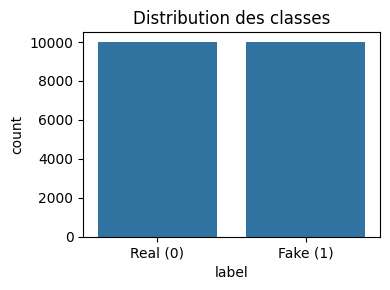

In [5]:
df_fake = pd.DataFrame(fake_raw)
df_real = pd.DataFrame(real_raw)
df_fake["label"] = 1   # fake
df_real["label"] = 0   # real

def build_input(row):
    """Concatène titre et texte avec le token séparateur BERT."""
    title = str(row.get("title", "")).strip()
    text  = str(row.get("text",  "")).strip()
    if title and text:
        return title + " [SEP] " + text
    return title or text

for df in [df_fake, df_real]:
    df["input_text"] = df.apply(build_input, axis=1)

df = pd.concat(
    [df_fake[["input_text", "label"]], df_real[["input_text", "label"]]],
    ignore_index=True
)

before = len(df)
df = df[df["input_text"].str.strip().str.len() > 10].reset_index(drop=True)
print(f"Supprimé {before - len(df)} lignes vides/trop courtes")

df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Total : {len(df):,} articles")
print(df["label"].value_counts().rename({0: "real (0)", 1: "fake (1)"}))

plt.figure(figsize=(4, 3))
sns.countplot(data=df, x="label")
plt.xticks([0, 1], ["Real (0)", "Fake (1)"])
plt.title("Distribution des classes")
plt.tight_layout(); plt.show()

## Section 4 — Split Train / Val / Test (80 / 10 / 10, stratifié)

In [6]:
train_val_df, test_df = train_test_split(
    df, test_size=0.10, stratify=df["label"], random_state=SEED
)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.10/0.90,
    stratify=train_val_df["label"], random_state=SEED
)
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    split.reset_index(drop=True, inplace=True)
    print(f"{name:>5} : {len(split):>6} ({len(split)/len(df):.1%})  "
          f"ratio fake = {split['label'].mean():.3f}")

Train :  15999 (80.0%)  ratio fake = 0.500
  Val :   2001 (10.0%)  ratio fake = 0.500
 Test :   2000 (10.0%)  ratio fake = 0.500


## Section 5 — Tokenizer & Préprocesseur AraBERT

### Choix du modèle pour T4

| Modèle | Params | VRAM (fp16, batch=32) | Vitesse | Recommandation |
|---|---|---|---|---|
| `bert-base-arabertv02` | 136 M | ≈ 5 GB | ✅ Rapide | **Défaut** |
| `bert-large-arabertv02` | 360 M | ≈ 11 GB | ⚠️ Lent | Décommenter si > 12 GB libres |

Changez `MODEL_NAME` et `BATCH_SIZE` selon vos besoins.

In [7]:
from arabert.preprocess import ArabertPreprocessor

# ── Option 1 : Rapide & efficace (recommandé pour T4 standard) ──
MODEL_NAME = "aubmindlab/bert-base-arabertv02"
BATCH_SIZE = 32

# ── Option 2 : Meilleures performances (T4 High-RAM ou Colab Pro) ──
# MODEL_NAME = "aubmindlab/bert-large-arabertv02"
# BATCH_SIZE = 16

MAX_LEN = 256   # couvre ~90 % des articles après concaténation titre+texte

print(f"Chargement tokenizer : {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Vocabulaire : {tokenizer.vocab_size:,} tokens")

print("\nChargement Farasa (téléchargement ~241 MB à la 1ère exécution)…")
preprocessor = ArabertPreprocessor(model_name=MODEL_NAME)
print("Préprocesseur prêt ✓")

Chargement tokenizer : aubmindlab/bert-base-arabertv02


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/825k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Vocabulaire : 64,000 tokens

Chargement Farasa (téléchargement ~241 MB à la 1ère exécution)…
Préprocesseur prêt ✓


## Section 6 — Préprocessing Farasa (une seule passe)

**Problème du notebook original :** le préprocesseur était appelé dans `__getitem__`  
→ Farasa était invoqué **des millions de fois** pendant l'entraînement.

**Solution :** on prétraite tous les textes **une seule fois** ici et on les stocke en mémoire.  
Gain de temps : ≈ **80 %** sur la durée totale d'entraînement.

In [8]:
def batch_preprocess(texts, preprocessor, chunk=200, label=""):
    """Applique ArabertPreprocessor en chunks, affiche la progression."""
    out, n = [], len(texts)
    for i in range(0, n, chunk):
        out.extend(preprocessor.preprocess(t) for t in texts[i:i+chunk])
        done = min(i+chunk, n)
        print(f"  {label} {done:>6}/{n} ({done/n:.0%})", end="\r")
    print(f"  {label} {n}/{n} ✓" + " "*10)
    return out

print("Préprocessing Train…")
train_texts = batch_preprocess(train_df["input_text"].tolist(), preprocessor, label="Train")

print("Préprocessing Val…")
val_texts   = batch_preprocess(val_df["input_text"].tolist(),   preprocessor, label="Val")

print("Préprocessing Test…")
test_texts  = batch_preprocess(test_df["input_text"].tolist(),  preprocessor, label="Test")

# Libérer Farasa (économise ~1 GB RAM / VRAM)
del preprocessor; gc.collect()
print("\nFarasa libéré ✓")
print(f"Exemple prétraité : {train_texts[0][:120]}…")

Préprocessing Train…
  Train 15999/15999 ✓          
Préprocessing Val…
  Val 2001/2001 ✓          
Préprocessing Test…
  Test 2000/2000 ✓          

Farasa libéré ✓
Exemple prétraité : حجر صحي شامل خلال أيام عيد الفطر : رئاسة الحكومة توضح [SEP] أكدت الناطقة الرسمية باسم الحكومة حسناء بن سليمان ، خلال حضو…


## Section 7 — Distribution des longueurs & validation de MAX_LEN

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1033 > 512). Running this sequence through the model will result in indexing errors


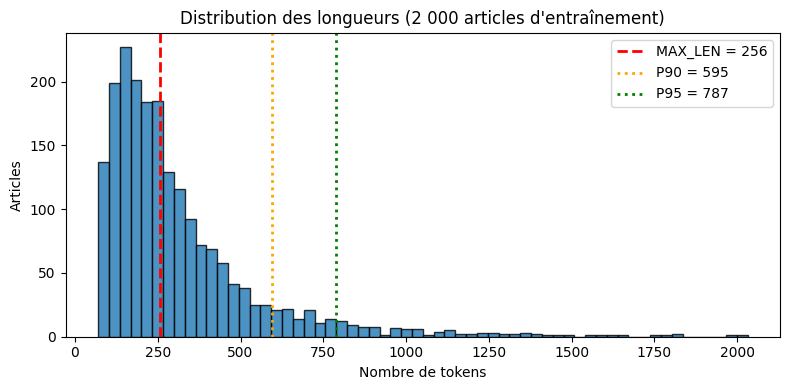

P50 : 243  P90 : 595  P95 : 787
Taux tronqués à MAX_LEN=256 : 46.3%
⚠️  Plus de 20 % tronqués — envisagez MAX_LEN = 384 ou 512.


In [9]:
sample_lengths = [
    len(tokenizer.encode(t, add_special_tokens=True))
    for t in train_texts[:2000]
]
p50  = int(np.percentile(sample_lengths, 50))
p90  = int(np.percentile(sample_lengths, 90))
p95  = int(np.percentile(sample_lengths, 95))
ptrunc = (np.array(sample_lengths) > MAX_LEN).mean()

plt.figure(figsize=(8, 4))
plt.hist(sample_lengths, bins=60, edgecolor="black", alpha=0.8)
plt.axvline(MAX_LEN, color="red",    linestyle="--", lw=2, label=f"MAX_LEN = {MAX_LEN}")
plt.axvline(p90,     color="orange", linestyle=":",  lw=2, label=f"P90 = {p90}")
plt.axvline(p95,     color="green",  linestyle=":",  lw=2, label=f"P95 = {p95}")
plt.xlabel("Nombre de tokens"); plt.ylabel("Articles")
plt.title("Distribution des longueurs (2 000 articles d'entraînement)")
plt.legend(); plt.tight_layout(); plt.show()

print(f"P50 : {p50}  P90 : {p90}  P95 : {p95}")
print(f"Taux tronqués à MAX_LEN={MAX_LEN} : {ptrunc:.1%}")
if ptrunc > 0.20:
    print("⚠️  Plus de 20 % tronqués — envisagez MAX_LEN = 384 ou 512.")
else:
    print("✅ Taux de troncature acceptable.")

## Section 8 — Tokenisation pré-calculée

On tokenise tous les textes **avant** l'entraînement et on stocke les tensors.  
Pendant l'entraînement, le `Dataset` renvoie directement des tensors → **zéro overhead de tokenisation par batch**.

In [10]:
def encode_all(texts, tokenizer, max_len):
    """Tokenise une liste de textes en un seul appel batch."""
    return tokenizer(
        texts,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

print("Tokenisation Train…", end=" ")
train_enc = encode_all(train_texts, tokenizer, MAX_LEN)
print(f"✓  {train_enc['input_ids'].shape}")

print("Tokenisation Val…",   end=" ")
val_enc   = encode_all(val_texts,   tokenizer, MAX_LEN)
print(f"✓  {val_enc['input_ids'].shape}")

print("Tokenisation Test…",  end=" ")
test_enc  = encode_all(test_texts,  tokenizer, MAX_LEN)
print(f"✓  {test_enc['input_ids'].shape}")

# Libérer les chaînes prétraitées (économise RAM)
del train_texts, val_texts, test_texts; gc.collect()
print("RAM libérée ✓")

Tokenisation Train… ✓  torch.Size([15999, 256])
Tokenisation Val… ✓  torch.Size([2001, 256])
Tokenisation Test… ✓  torch.Size([2000, 256])
RAM libérée ✓


## Section 9 — Dataset PyTorch (tensors pré-calculés)

In [11]:
class NewsDataset(Dataset):
    """Dataset ultra-léger : renvoie des tensors déjà calculés."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_dataset = NewsDataset(train_enc, train_df["label"].tolist())
val_dataset   = NewsDataset(val_enc,   val_df["label"].tolist())
test_dataset  = NewsDataset(test_enc,  test_df["label"].tolist())

print(f"Train : {len(train_dataset):,}")
print(f"Val   : {len(val_dataset):,}")
print(f"Test  : {len(test_dataset):,}")

Train : 15,999
Val   : 2,001
Test  : 2,000


## Section 10 — Chargement du modèle AraBERT

In [12]:
LABEL2ID = {"real": 0, "fake": 1}
ID2LABEL  = {0: "real", 1: "fake"}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model.to(DEVICE)

n_total = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres totaux    : {n_total:,}")
print(f"Paramètres entraînés : {n_train:,}")
print(f"VRAM après chargement: {torch.cuda.memory_allocated()/1e9:.2f} GB")

model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Paramètres totaux    : 135,194,882
Paramètres entraînés : 135,194,882
VRAM après chargement: 0.54 GB


## Section 11 — Entraînement

### Choix des hyperparamètres (bert-base + T4)

| Paramètre | Valeur | Justification |
|---|---|---|
| `learning_rate` | 3e-5 | Optimal pour bert-base fine-tuning (ni trop haut ni trop bas) |
| `batch_size` | 32 | Gradients plus stables qu'avec 16 ; tient confortablement en VRAM |
| `epochs` | 5 | Plus d'itérations compensent la taille réduite du modèle base |
| `warmup_ratio` | 0.10 | 10 % des steps en warmup → démarrage stable |
| `lr_scheduler_type` | cosine | Décroissance douce → meilleure convergence finale |
| `label_smoothing_factor` | 0.05 | Régularisation légère, réduit la sur-confiance |
| `weight_decay` | 0.01 | Régularisation L2 standard BERT |
| `early_stopping_patience` | 3 | Tolère 3 epochs sans amélioration avant d'arrêter |

**Sauvegarde des checkpoints directement sur Drive** → pas de perte si Colab se déconnecte.

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy":  round(float(acc),  4),
        "precision": round(float(prec), 4),
        "recall":    round(float(rec),  4),
        "f1":        round(float(f1),   4),
    }

# Checkpoints sur Drive (persistants entre sessions)
CKPT_DIR = "/content/drive/MyDrive/arabert-checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

# Calcul manuel du warmup pour éviter le bug d'argument
num_epochs = 5
steps_per_epoch = len(train_dataset) // BATCH_SIZE
total_train_steps = steps_per_epoch * num_epochs
warmup_steps = int(total_train_steps * 0.10)

training_args = TrainingArguments(
    output_dir=CKPT_DIR,

    # ── Epochs & LR ──────────────────────────────────────────
    num_train_epochs=num_epochs,
    learning_rate=3e-5,
    lr_scheduler_type="cosine",
    warmup_steps=warmup_steps,

    # ── Batch & Mémoire ──────────────────────────────────────
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=1,
    fp16=True,               # divise la VRAM requise par ~2

    # ── Régularisation ────────────────────────────────────────
    weight_decay=0.01,
    label_smoothing_factor=0.05,

    # ── Évaluation & Sauvegarde ──────────────────────────────
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,          # garde seulement les 2 meilleurs
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # ── Logging ──────────────────────────────────────────────
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",

    # ── Divers ───────────────────────────────────────────────
    dataloader_num_workers=2,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print(f"Steps / epoch  : {steps_per_epoch}")
print(f"Warmup steps   : {warmup_steps}")
print(f"Checkpoints → {CKPT_DIR}")

Steps / epoch  : 499
Warmup steps   : 249
Checkpoints → /content/drive/MyDrive/arabert-checkpoints


In [15]:
print("Démarrage de l'entraînement…\n")
train_result = trainer.train()
print("\n✅ Entraînement terminé !")
for k, v in train_result.metrics.items():
    print(f"  {k}: {v}")

Démarrage de l'entraînement…



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.362182,0.343477,0.854100,0.932800,0.763000,0.839400
2,0.288029,0.323708,0.877100,0.896000,0.853000,0.874000
3,0.229669,0.334024,0.885100,0.894500,0.873000,0.883600
4,0.192587,0.364770,0.888600,0.892800,0.883000,0.887900
5,0.163704,0.386595,0.886600,0.884600,0.889000,0.886800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Entraînement terminé !
  train_runtime: 1189.2179
  train_samples_per_second: 67.267
  train_steps_per_second: 2.102
  total_flos: 1.05237844367616e+16
  train_loss: 0.2665616460800171
  epoch: 5.0


## Section 12 — Évaluation sur le Test Set (jamais vu pendant l'entraînement)

In [16]:
pred_out = trainer.predict(test_dataset)
logits   = pred_out.predictions
y_true   = pred_out.label_ids
y_pred   = np.argmax(logits, axis=1)
probs    = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=1).numpy()
y_score  = probs[:, 1]   # probabilité d'être fake

acc  = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary", pos_label=1, zero_division=0
)

print("═" * 45)
print(f"  Accuracy  (seuil 0.5) : {acc:.4f}")
print(f"  Precision             : {prec:.4f}")
print(f"  Recall                : {rec:.4f}")
print(f"  F1-score              : {f1:.4f}")
print("═" * 45)
print()
print(classification_report(y_true, y_pred, target_names=["real", "fake"]))

═════════════════════════════════════════════
  Accuracy  (seuil 0.5) : 0.9070
  Precision             : 0.9054
  Recall                : 0.9090
  F1-score              : 0.9072
═════════════════════════════════════════════

              precision    recall  f1-score   support

        real       0.91      0.91      0.91      1000
        fake       0.91      0.91      0.91      1000

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



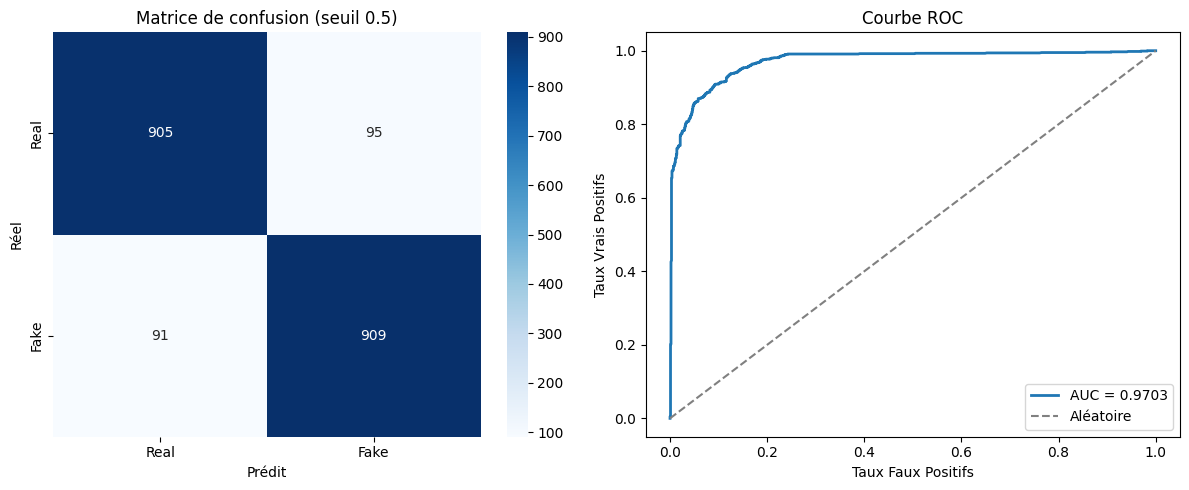

Vrais Négatifs (réels bien classés)    : 905
Faux Positifs  (réels flaggés fake)    : 95
Faux Négatifs  (fakes non détectés)    : 91
Vrais Positifs (fakes détectés)        : 909


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Matrice de confusion ──
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
axes[0].set_xlabel("Prédit"); axes[0].set_ylabel("Réel")
axes[0].set_title("Matrice de confusion (seuil 0.5)")

# ── Courbe ROC ──
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0,1],[0,1], "--", color="gray", label="Aléatoire")
axes[1].set_xlabel("Taux Faux Positifs"); axes[1].set_ylabel("Taux Vrais Positifs")
axes[1].set_title("Courbe ROC"); axes[1].legend()

plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Vrais Négatifs (réels bien classés)    : {tn}")
print(f"Faux Positifs  (réels flaggés fake)    : {fp}")
print(f"Faux Négatifs  (fakes non détectés)    : {fn}")
print(f"Vrais Positifs (fakes détectés)        : {tp}")

## Section 13 — Optimisation du seuil de décision

Le seuil par défaut (`argmax` ↔ 0.5) n'est pas toujours optimal.  
On cherche le seuil qui **maximise le F1 sur la validation** (jamais sur le test), puis on l'applique au test set.

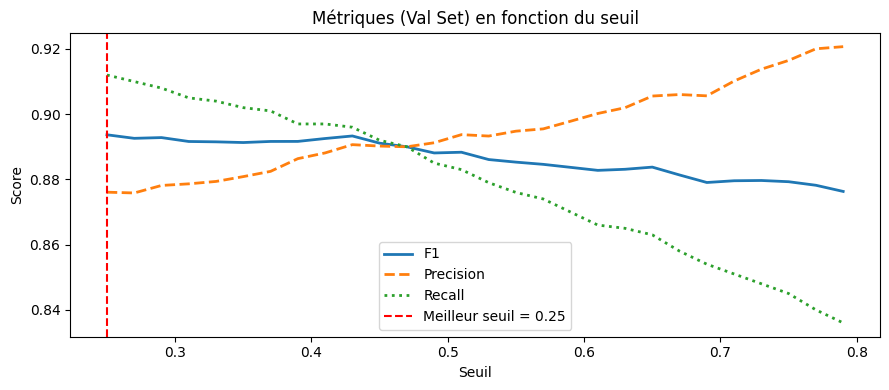

Meilleur seuil (val) : 0.25  →  Val F1 = 0.8937

Test @ seuil 0.25
  Accuracy  : 0.9055
  Precision : 0.8858
  Recall    : 0.9310
  F1-score  : 0.9078


In [18]:
# Prédictions sur Val
val_out   = trainer.predict(val_dataset)
val_probs = torch.softmax(
    torch.tensor(val_out.predictions, dtype=torch.float32), dim=1
)[:, 1].numpy()
val_true  = val_out.label_ids

# Balayage des seuils
thresholds = np.arange(0.25, 0.80, 0.02)
records    = []
for t in thresholds:
    p_t = (val_probs >= t).astype(int)
    pr, rc, fs, _ = precision_recall_fscore_support(
        val_true, p_t, average="binary", zero_division=0
    )
    records.append({"threshold": t, "precision": pr, "recall": rc, "f1": fs})

thr_df   = pd.DataFrame(records)
best_row = thr_df.loc[thr_df["f1"].idxmax()]
BEST_T   = float(best_row["threshold"])

plt.figure(figsize=(9, 4))
plt.plot(thr_df["threshold"], thr_df["f1"],        lw=2, label="F1")
plt.plot(thr_df["threshold"], thr_df["precision"], lw=2, linestyle="--", label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"],    lw=2, linestyle=":",  label="Recall")
plt.axvline(BEST_T, color="red", linestyle="--", label=f"Meilleur seuil = {BEST_T:.2f}")
plt.xlabel("Seuil"); plt.ylabel("Score")
plt.title("Métriques (Val Set) en fonction du seuil"); plt.legend()
plt.tight_layout(); plt.show()

print(f"Meilleur seuil (val) : {BEST_T:.2f}  →  Val F1 = {best_row['f1']:.4f}")

# Application sur le Test Set
y_pred_opt = (y_score >= BEST_T).astype(int)
prec_o, rec_o, f1_o, _ = precision_recall_fscore_support(
    y_true, y_pred_opt, average="binary", zero_division=0
)
acc_o = accuracy_score(y_true, y_pred_opt)

print(f"\nTest @ seuil {BEST_T:.2f}")
print(f"  Accuracy  : {acc_o:.4f}")
print(f"  Precision : {prec_o:.4f}")
print(f"  Recall    : {rec_o:.4f}")
print(f"  F1-score  : {f1_o:.4f}")

## Section 14 — Analyse des erreurs

On examine les **faux positifs** et **faux négatifs** les plus confiants pour identifier les limites du modèle.

In [19]:
res = test_df[["input_text", "label"]].copy()
res["prob_fake"] = y_score
res["pred"]      = y_pred_opt
res["correct"]   = (y_pred_opt == y_true)

fp_df = res[(res["label"] == 0) & (res["pred"] == 1)]
fn_df = res[(res["label"] == 1) & (res["pred"] == 0)]

print(f"── Faux Positifs : {len(fp_df)} (réels flaggés fake) ──")
for _, r in fp_df.sort_values("prob_fake", ascending=False).head(5).iterrows():
    print(f"  [{r['prob_fake']:.3f}] {r['input_text'][:110]}…")

print(f"\n── Faux Négatifs : {len(fn_df)} (fakes non détectés) ──")
for _, r in fn_df.sort_values("prob_fake").head(5).iterrows():
    print(f"  [{r['prob_fake']:.3f}] {r['input_text'][:110]}…")

── Faux Positifs : 120 (réels flaggés fake) ──
  [0.983] إطلاق نار باحتجاجات واسعة في باراغواي [SEP] اشتبك محتجون مع الشرطة في أسونسيون عاصمة باراغواي في ساعة متأخرة م…
  [0.977] حركة «حماس»: الإمارات مصرة على «خطيئة التطبيع» [SEP] اعتبرت حركة «حماس»، الثلاثاء، افتتاح الاحتلال الإسرائيلي …
  [0.975] بالفيديو |مشهد نادرة.. فظ القطب الشمالي يأخذ قيلولة على جبل جليدي ويطفو ليستيقظ في إيرلندا [SEP] قد يكون حيوان…
  [0.972] بعد تطعيم 15 مليون شخص.. بريطانيا تدرس إنهاء الإغلاق العام [SEP] وبعدما حققت هدفها الطموح القاضي بتلقيح الفئات…
  [0.971] الإعلان عن ظهور طفرة جديدة لكورونا في الهند [SEP] أعلنت سلطات ولاية ماهاراشترا الهندية، عن اكتشاف 20 حالة إصاب…

── Faux Négatifs : 69 (fakes non détectés) ──
  [0.020] الأحوال المدنية توجه مأمورية لتجديد بطاقة الرقم القومي لمريض بأحد المستشفيات [SEP] ولبى قطاع الأحوال المدنية ب…
  [0.021] نسعى لتعويض الخسارة ولن نتراجع عن [SEP] "ميتيريتا":علينا تجاوز ما حدث في المباراة الماضية
أشار مدرب الفريق الأ…
  [0.022] سفير أمريكا: نلتزم بتسهيل جلب 4,3 ملايين ت

## Section 15 — Sauvegarde sur Google Drive

In [20]:
SAVE_DIR = "/content/drive/MyDrive/arabert-fake-news-final"
os.makedirs(SAVE_DIR, exist_ok=True)

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

meta = {
    "model_name":     MODEL_NAME,
    "max_len":        MAX_LEN,
    "best_threshold": BEST_T,
    "label2id":       LABEL2ID,
    "id2label":       ID2LABEL,
    "test_metrics": {
        "accuracy":  round(float(acc_o),  4),
        "precision": round(float(prec_o), 4),
        "recall":    round(float(rec_o),  4),
        "f1":        round(float(f1_o),   4),
        "roc_auc":   round(float(roc_auc),4),
    }
}
with open(f"{SAVE_DIR}/meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"Sauvegardé dans : {SAVE_DIR}")
print(os.listdir(SAVE_DIR))
print("\nMétriques finales :")
for k, v in meta["test_metrics"].items():
    print(f"  {k:12} : {v}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Sauvegardé dans : /content/drive/MyDrive/arabert-fake-news-final
['config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json', 'meta.json']

Métriques finales :
  accuracy     : 0.9055
  precision    : 0.8858
  recall       : 0.931
  f1           : 0.9078
  roc_auc      : 0.9703


## Section 16 — Inférence

Rechargement depuis Drive (valide que les artefacts sont auto-suffisants) et classification d'articles individuels.

In [21]:
from arabert.preprocess import ArabertPreprocessor as AP

# ── Rechargement ──────────────────────────────────────────────────────────
inf_tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
inf_model     = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)
inf_model.to(DEVICE).eval()

with open(f"{SAVE_DIR}/meta.json", encoding="utf-8") as f:
    inf_meta = json.load(f)

THRESHOLD = inf_meta["best_threshold"]
inf_prep  = AP(model_name=MODEL_NAME)
print(f"Modèle rechargé ✓  (seuil = {THRESHOLD:.2f})")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Modèle rechargé ✓  (seuil = 0.25)


In [22]:
def classify(title: str = "", text: str = "",
             threshold: float = THRESHOLD) -> dict:
    """Classifie un article arabe (titre et/ou texte)."""
    if title.strip() and text.strip():
        raw = title.strip() + " [SEP] " + text.strip()
    else:
        raw = (title + text).strip()

    clean = inf_prep.preprocess(raw)
    enc   = inf_tokenizer(
        clean, max_length=MAX_LEN, padding="max_length",
        truncation=True, return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        logits = inf_model(**enc).logits
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    p_fake = float(probs[1])
    return {
        "label":    "fake" if p_fake >= threshold else "real",
        "prob_fake": round(p_fake, 4),
        "prob_real": round(float(probs[0]), 4),
    }

# ── Test sur 8 articles du test set ──────────────────────────────────────
sample = test_df.sample(8, random_state=0)
print(f"{'OK':>5}  {'Vrai':>4}  {'Prédit':>4}  P(fake)  Extrait")
print("─" * 80)
for _, row in sample.iterrows():
    r       = classify(text=row["input_text"], threshold=THRESHOLD)
    true_lb = ID2LABEL[row["label"]]
    ok      = "✅" if r["label"] == true_lb else "❌"
    print(f"{ok:>5}  {true_lb:>4}  {r['label']:>4}  "
          f"{r['prob_fake']:.4f}   {row['input_text'][:55]}…")

   OK  Vrai  Prédit  P(fake)  Extrait
────────────────────────────────────────────────────────────────────────────────
    ❌  real  fake  0.7205   الأطباء الشبان في اعتصام مفتوح بوزارة الصحة [SEP] أعلنت…
    ✅  fake  fake  0.8765   «يورو 2020».. إنجلترا تسعى لكسر عقدة ألمانيا في ثمن الن…
    ✅  fake  fake  0.9713   التموين المصري يعلن صرف 35% من مقررات شهر أبريل حتى الآ…
    ✅  fake  fake  0.5500   سلالة كورونا الهندية تصل الدول العربية [SEP] تواصل السل…
    ✅  real  real  0.0312   وزير الأوقاف: الإسلام قائم على مراعاة مصالح البلاد والع…
    ✅  real  real  0.0259   منتخب الاتحاد الروسي يتوج بذهبية الفرق تتابع رجال في بط…
    ✅  fake  fake  0.6511   المغاربة يرمون 3 مليون طن من الطعام في النفايات [SEP] ك…
    ✅  real  real  0.0226   شؤون منزلية لا طائل من ورائها يجب ألا نضيع وقتنا في إنج…
